# Lab 1: Social_Network_Ads (Logistic Regression)

We follow the slides starting at `Lab 1` and build the requested two-dimensional classifier using `Age` and `EstimatedSalary` to predict `Purchased`.

$$
\Pr(Y=1 \mid x)=\sigma\!\left(\beta_0+\beta_1\,\mathrm{Age}+\beta_2\,\mathrm{EstimatedSalary}\right),
\qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_PATH = Path("Dataset1.csv")
point_palette = {"No purchase": "#4C78A8", "Purchase": "#E45756"}
probability_cmap = LinearSegmentedColormap.from_list(
    "purchase_probability",
    ["#EEF4FF", "#F9F6F0", "#FFD9CC"],
)
salary_formatter = FuncFormatter(lambda value, _: f"${value/1000:.0f}k")


def plot_feature_space(ax, frame, model=None, title=""):
    plot_frame = frame.copy()
    plot_frame["PurchasedLabel"] = plot_frame["Purchased"].map({0: "No purchase", 1: "Purchase"})

    if model is not None:
        age = np.linspace(plot_frame["Age"].min() - 2, plot_frame["Age"].max() + 2, 300)
        salary = np.linspace(
            plot_frame["EstimatedSalary"].min() - 5000,
            plot_frame["EstimatedSalary"].max() + 5000,
            300,
        )
        age_grid, salary_grid = np.meshgrid(age, salary)
        grid = pd.DataFrame(
            {"Age": age_grid.ravel(), "EstimatedSalary": salary_grid.ravel()}
        )
        proba_grid = model.predict_proba(grid)[:, 1].reshape(age_grid.shape)
        ax.contourf(
            age_grid,
            salary_grid,
            proba_grid,
            levels=np.linspace(0, 1, 11),
            cmap=probability_cmap,
            alpha=0.55,
        )
        ax.contour(
            age_grid,
            salary_grid,
            proba_grid,
            levels=[0.5],
            colors="#1f1f1f",
            linewidths=2,
            linestyles="--",
        )

    sns.scatterplot(
        data=plot_frame,
        x="Age",
        y="EstimatedSalary",
        hue="PurchasedLabel",
        hue_order=["No purchase", "Purchase"],
        palette=point_palette,
        s=70,
        alpha=0.9,
        linewidth=0.6,
        edgecolor="white",
        ax=ax,
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Estimated salary")
    ax.yaxis.set_major_formatter(salary_formatter)
    ax.legend(title="Purchased", frameon=True)


def plot_confusion(ax, cm, title):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette("#4C78A8", as_cmap=True),
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticklabels([0, 1])
    ax.set_yticklabels([0, 1], rotation=0)


## Step 1 - Load & Inspect the Dataset

In [2]:

df = pd.read_csv(DATA_PATH)
features = ["Age", "EstimatedSalary"]
target = "Purchased"

X = df[features]
y = df[target]

overview = pd.DataFrame(
    {
        "Value": [
            df.shape[0],
            df.shape[1],
            len(features),
            int(y.value_counts().loc[0]),
            int(y.value_counts().loc[1]),
            round(y.mean(), 4),
            int(df.isna().sum().sum()),
        ]
    },
    index=[
        "Observations",
        "Variables in CSV",
        "Predictors used",
        "Class 0 count",
        "Class 1 count",
        "Purchase rate",
        "Missing values",
    ],
)

structure = pd.DataFrame({"dtype": df.dtypes.astype(str)}).T
missing = pd.DataFrame(df.isna().sum()).T
missing.index = ["Missing values"]

display(df.head())
display(structure)
display(overview)
display(missing)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


,User ID,Gender,Age,EstimatedSalary,Purchased
dtype,int64,object,int64,int64,int64


,Value
Observations,400.0000
Variables in CSV,5.0000
Predictors used,2.0000
Class 0 count,257.0000
Class 1 count,143.0000
Purchase rate,0.3575
Missing values,0.0000


,User ID,Gender,Age,EstimatedSalary,Purchased
Missing values,0,0,0,0,0


**Answer.** The CSV contains 400 observations and 5 variables, and the model uses the two requested predictors `Age` and `EstimatedSalary`. The target is not balanced because $\hat P(Y=1)=143/400=0.3575$ and $\hat P(Y=0)=257/400=0.6425$. There are no missing values in any column.

## Step 2 - Visualize the Classes (Separability?)

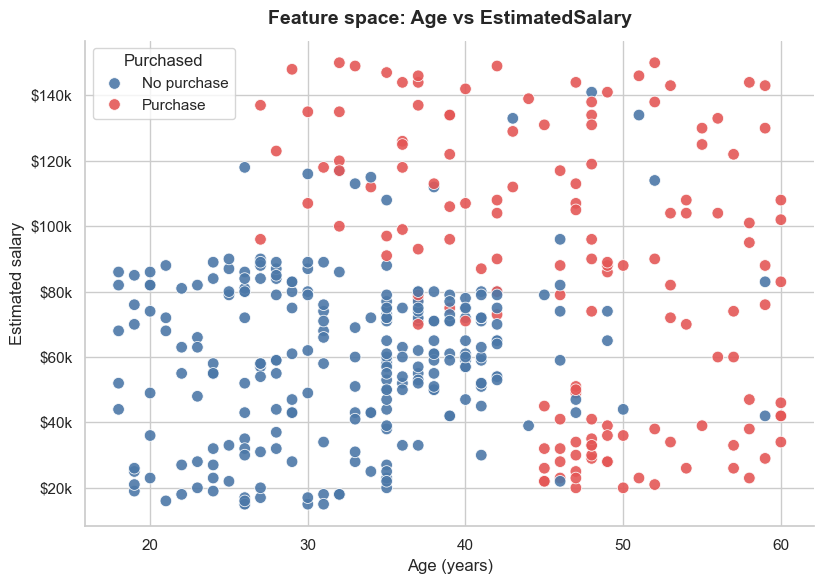

In [3]:

fig, ax = plt.subplots(figsize=(8.4, 6))
plot_feature_space(ax, df[features + [target]], title="Feature space: Age vs EstimatedSalary")
plt.tight_layout()
plt.show()


**Answer.** The classes are not perfectly linearly separable because the purchase class is concentrated in the older, higher-salary region, but the two groups still overlap. A linear decision boundary satisfies

$$
\beta_0 + \beta_1\,\mathrm{Age} + \beta_2\,\mathrm{EstimatedSalary} = 0,
$$

so it appears as a straight line in the feature plane. Since both fitted coefficients are positive, that line has a negative slope.

## Step 3 - Fit Logistic Regression (Train/Test)

,Set,Size
0,Train,300
1,Test,100


,Coefficient,Sign,Interpretation step,Odds multiplier for step
Age,0.222001,positive,+1 year,1.249
EstimatedSalary,0.000038,positive,+$10k salary,1.458


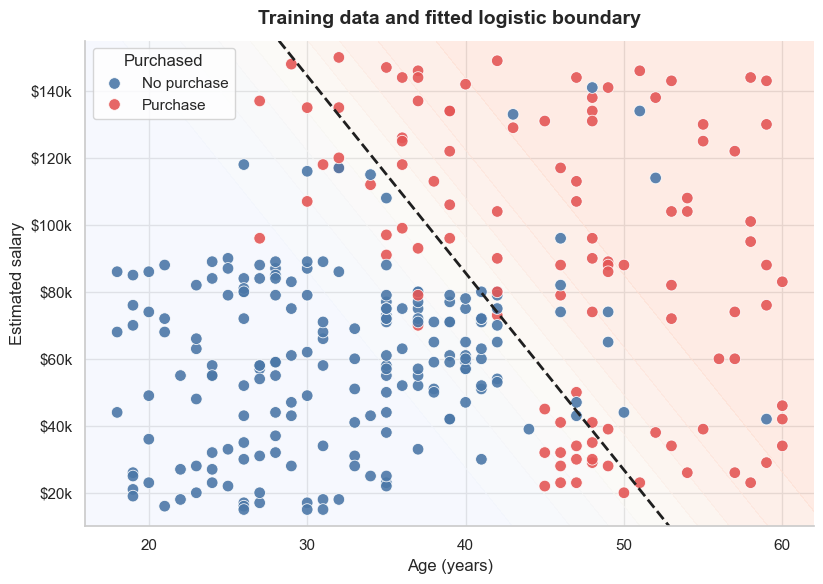

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

beta0 = clf.intercept_[0]
beta_age, beta_salary = clf.coef_[0]

split_sizes = pd.DataFrame({"Set": ["Train", "Test"], "Size": [len(X_train), len(X_test)]})
coef_table = pd.DataFrame(
    {
        "Coefficient": [beta_age, beta_salary],
        "Sign": [
            "positive" if beta_age > 0 else "negative",
            "positive" if beta_salary > 0 else "negative",
        ],
        "Interpretation step": ["+1 year", "+$10k salary"],
        "Odds multiplier for step": [np.exp(beta_age), np.exp(beta_salary * 10000)],
    },
    index=["Age", "EstimatedSalary"],
)

display(split_sizes)
display(coef_table.round({"Coefficient": 6, "Odds multiplier for step": 3}))

train_frame = X_train.copy()
train_frame["Purchased"] = y_train.values

fig, ax = plt.subplots(figsize=(8.4, 6))
plot_feature_space(ax, train_frame, model=clf, title="Training data and fitted logistic boundary")
plt.tight_layout()
plt.show()


**Answer.** Both fitted coefficients are positive, so increasing either predictor increases the log-odds of purchase. Therefore both predictors increase the odds of purchase. Interpreted on practical scales, the fitted model gives about a $1.249\times$ change in odds for one additional year of age and about a $1.458\times$ change in odds for an additional 10 thousand dollars of salary. The raw coefficient magnitudes should not be compared directly because the predictors are measured in different units.

## Step 4 - Predictions and Model Evaluation

,Metric,Value
0,Accuracy,0.840
1,Precision,0.857
2,Recall,0.667
3,F1-score,0.750
4,ROC AUC,0.910


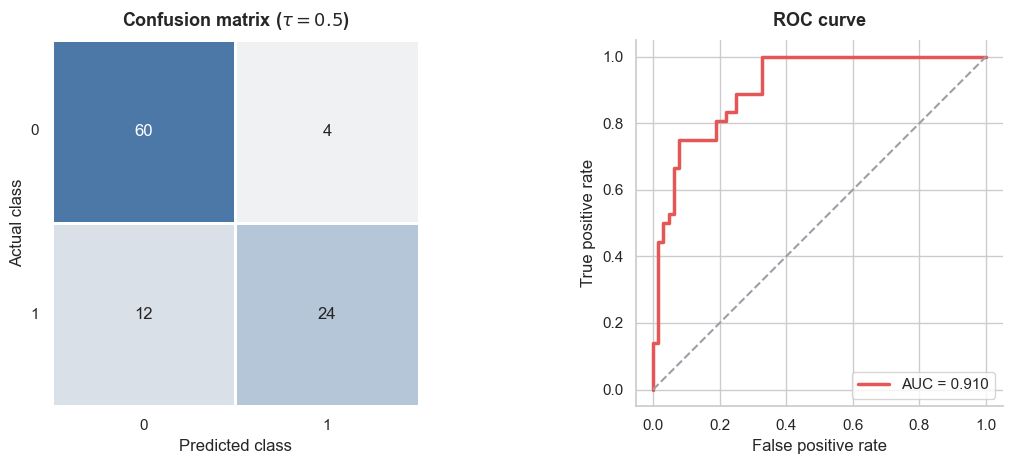

In [5]:

y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
        "Value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_proba),
        ],
    }
)

display(metrics.round(3))

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_confusion(axes[0], cm, r"Confusion matrix ($\tau=0.5$)")

axes[1].plot(fpr, tpr, color="#E45756", linewidth=2.5, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#9AA0A6", linewidth=1.5)
axes[1].set_title("ROC curve", fontsize=13, fontweight="bold", pad=10)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend(frameon=True)
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


**Answer.** Predicted probabilities are the fitted values $\hat p(x)=\Pr(Y=1\mid X=x)$, whereas predicted classes apply a thresholding rule. In this notebook the default classifier uses

$$
\hat y = \mathbf{1}\{\hat p(x) \ge 0.5\}.
$$

On the test set, the model reaches 84% accuracy. Accuracy alone is not sufficient because it depends on the threshold and hides the false-positive versus false-negative trade-off. The confusion matrix, precision, recall, F1-score, and ROC AUC provide a fuller evaluation.

## Step 5 - Effect of the Classification Threshold

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Recall
0,0.3,48,16,6,30,0.78,0.652,0.833
1,0.5,60,4,12,24,0.84,0.857,0.667
2,0.7,62,2,20,16,0.78,0.889,0.444


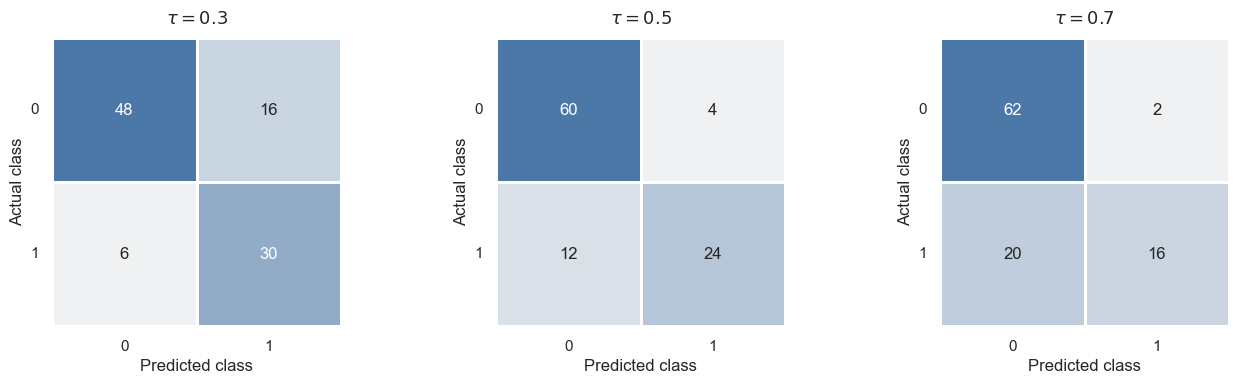

In [6]:

thresholds = [0.3, 0.5, 0.7]
rows = []
cms = {}

for tau in thresholds:
    pred_tau = (y_proba >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, pred_tau)
    tn, fp, fn, tp = cm_tau.ravel()
    cms[tau] = cm_tau
    rows.append(
        {
            "Threshold": tau,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Accuracy": accuracy_score(y_test, pred_tau),
            "Precision": precision_score(y_test, pred_tau, zero_division=0),
            "Recall": recall_score(y_test, pred_tau),
        }
    )

threshold_df = pd.DataFrame(rows)
display(threshold_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, tau in zip(axes, thresholds):
    plot_confusion(ax, cms[tau], fr"$\tau = {tau}$")
plt.tight_layout()
plt.show()


**Answer.** Lowering the threshold to $\tau=0.3$ labels more users as purchasers, so false positives rise from 4 to 16 while false negatives fall from 12 to 6. Recall therefore improves, but precision drops. Raising the threshold to $\tau=0.7$ has the opposite effect: false positives fall from 4 to 2 while false negatives rise from 12 to 20, so precision improves slightly but recall drops sharply. In short, lower thresholds favor recall, whereas higher thresholds favor precision.

## Step 6 - Regularization

The slides continue with a regularization extension. For a fair L1/L2 comparison, the predictors are standardized first because the penalty is applied directly to coefficient size.

,Penalty,C,Age coef (scaled),Salary coef (scaled),Test accuracy
0,L2,10.00,2.331,1.314,0.84
1,L2,1.00,2.144,1.211,0.84
2,L2,0.10,1.426,0.815,0.80
3,L2,0.01,0.518,0.318,0.77
4,L1,10.00,2.342,1.318,0.84
5,L1,1.00,2.214,1.238,0.84
6,L1,0.10,1.483,0.756,0.86
7,L1,0.01,0.000,0.000,0.64


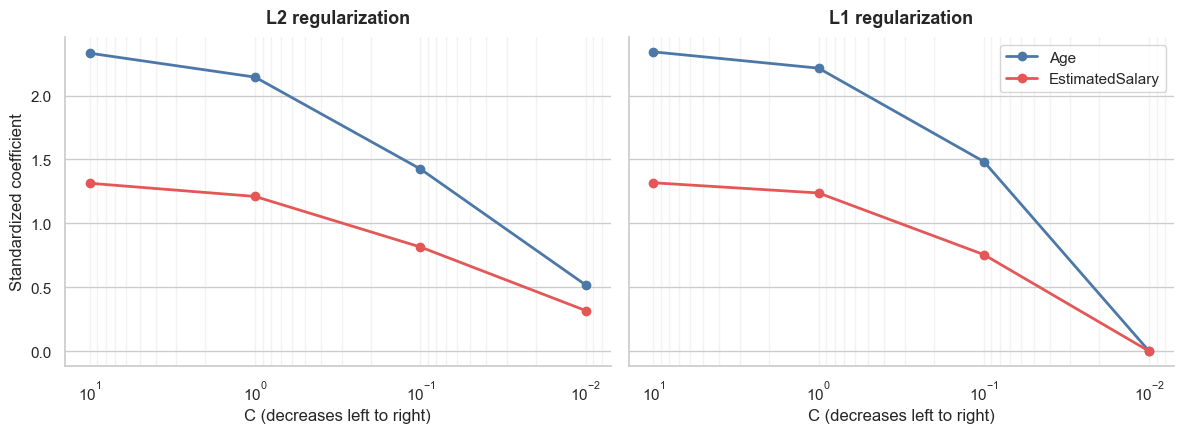

In [7]:

C_values = [10, 1, 0.1, 0.01]
records = []

for penalty in ["l2", "l1"]:
    for C in C_values:
        kwargs = {"penalty": penalty, "C": C, "max_iter": 5000}
        if penalty == "l1":
            kwargs["solver"] = "liblinear"

        regularized_model = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("logit", LogisticRegression(**kwargs)),
            ]
        )
        regularized_model.fit(X_train, y_train)

        beta_age_scaled, beta_salary_scaled = regularized_model.named_steps["logit"].coef_[0]
        records.append(
            {
                "Penalty": penalty.upper(),
                "C": C,
                "Age coef (scaled)": beta_age_scaled,
                "Salary coef (scaled)": beta_salary_scaled,
                "Test accuracy": accuracy_score(y_test, regularized_model.predict(X_test)),
            }
        )

reg_df = pd.DataFrame(records)
display(reg_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, penalty in zip(axes, ["L2", "L1"]):
    subset = reg_df[reg_df["Penalty"] == penalty].sort_values("C", ascending=False)
    ax.plot(subset["C"], subset["Age coef (scaled)"], marker="o", linewidth=2, color="#4C78A8", label="Age")
    ax.plot(subset["C"], subset["Salary coef (scaled)"], marker="o", linewidth=2, color="#E45756", label="EstimatedSalary")
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_title(f"{penalty} regularization", fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("C (decreases left to right)")
    ax.grid(True, which="both", axis="x", alpha=0.25)
axes[0].set_ylabel("Standardized coefficient")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


**Answer.** If interpretability is the priority, L1 regularization is the natural choice because it can set some coefficients exactly to zero and therefore produces a sparse model. If stability is the priority, L2 regularization is preferable because it shrinks coefficients smoothly instead of making abrupt variable-selection decisions. As $C$ decreases, regularization becomes stronger and the coefficients shrink toward zero. Under L1, that shrinkage is more aggressive and can drive coefficients exactly to zero. In this split, test accuracy stays close to 0.84 under mild regularization, reaches 0.86 for L1 with $C=0.1$, and drops sharply for very strong regularization, down to 0.64 at L1 with $C=0.01$, which is clear underfitting.

## Takeaway

With only two predictors, logistic regression gives an interpretable linear boundary, a strong ranking score with $\mathrm{ROC\ AUC} \approx 0.91$, and a clear precision-recall trade-off controlled by the classification threshold.